# Non-Abelian quantum geometric tensor and quantum metric

The quantum geometric tensor (QGT) generalizes the Berry curvature: its antisymmetric part *is*
the Berry curvature, and its symmetric part is the quantum metric, a measure of distance between
neighboring Bloch states,

$$
Q_{ij}^{mn}(\mathbf k) = \sum_{l\notin S}
\frac{\langle u_m|\partial_{k_i}H|u_l\rangle\langle u_l|\partial_{k_j}H|u_n\rangle}
{(E_m-E_l)(E_n-E_l)},\qquad m,n\in S
$$

Because only states *outside* the chosen band subspace $S$ enter the energy denominators, it stays
well defined even for (nearly) degenerate bands in $S$, unlike a single-band Kubo formula, and
`topology.chern_from_qgt` integrates its Berry-curvature part over the whole Brillouin zone,
independently reproducing the Wilson-loop `h.get_chern()`. The orbitals sit at their positions
in the geometry (`gauge="atomic"`, the default), which is what makes the curvature and the
metric respect the symmetry of the lattice at every k-point; `gauge="lattice"` drops the
positions from the Bloch phase, which leaves the Chern number unchanged but not the pointwise
geometry.

Chern number from the QGT       = 2.0000000018485276
Chern number from Wilson loops  = 2.000000000000003


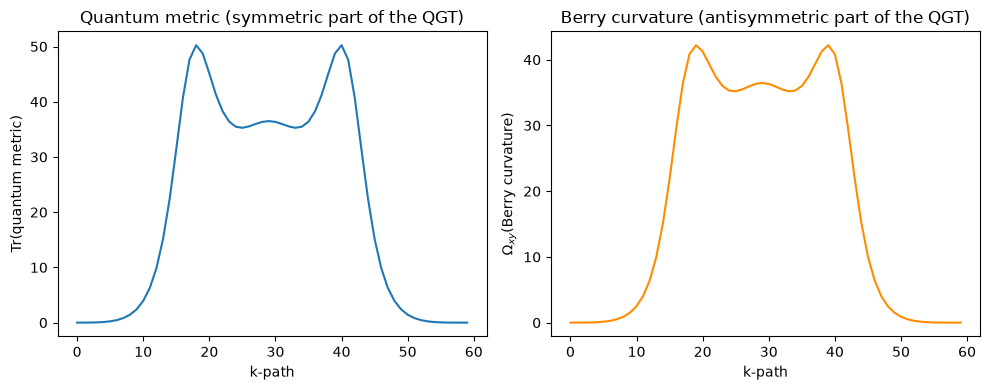

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian() # spinful by default
h.add_haldane(0.2)
h.shift_fermi(0.3) # put the Fermi level safely mid-gap

inds,gpath,omegapath = topology.quantum_geometric_tensor_path(h,occ_idxs=[0,1],nk=60)
C_qgt = topology.chern_from_qgt(h,nk=20,occ_idxs=[0,1])
print("Chern number from the QGT       =",C_qgt)
print("Chern number from Wilson loops  =",h.get_chern(nk=20))

# gpath/omegapath are already band-traced (occ_idxs=[0,1] summed inside
# quantum_geometric_tensor_path), leaving a dim x dim matrix in the *spatial*
# indices i,j at each k-point. Tr(quantum metric) = g_xx+g_yy is a sensible
# scalar, but the Berry curvature tensor is antisymmetric in i,j (Omega_ii=0
# by construction), so its trace vanishes identically -- the physical Berry
# curvature is the off-diagonal xy component, same as chern_from_qgt's
# omega_xy = berry_curvature_from_qgt(Qs)[:,0,1].
metric_trace = np.array([np.trace(g_k).real for g_k in gpath])
berry_xy = np.array([o_k[0,1].real for o_k in omegapath])

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(inds,metric_trace)
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Tr(quantum metric)")
axs[0].set_title("Quantum metric (symmetric part of the QGT)")
axs[1].plot(inds,berry_xy,c="darkorange")
axs[1].set_xlabel("k-path") ; axs[1].set_ylabel("$\\Omega_{xy}$(Berry curvature)")
axs[1].set_title("Berry curvature (antisymmetric part of the QGT)")
plt.tight_layout()
plt.show()

### The quantum geometry over the whole Brillouin zone
We will now look at the quantum metric and the Berry curvature over the Brillouin zone, with
`topology.quantum_geometric_tensor_mesh()`, which evaluates the tensor on a uniform k-mesh of
fractional coordinates, here mapped onto the reciprocal lattice vectors. For this large Haldane
coupling the gap at K and K' is almost as large as at the M points, so neither quantity is
concentrated at the valleys: both spread along the boundary of the Brillouin zone, the lines that
join K and K' through M, and draw the hexagonal zone.

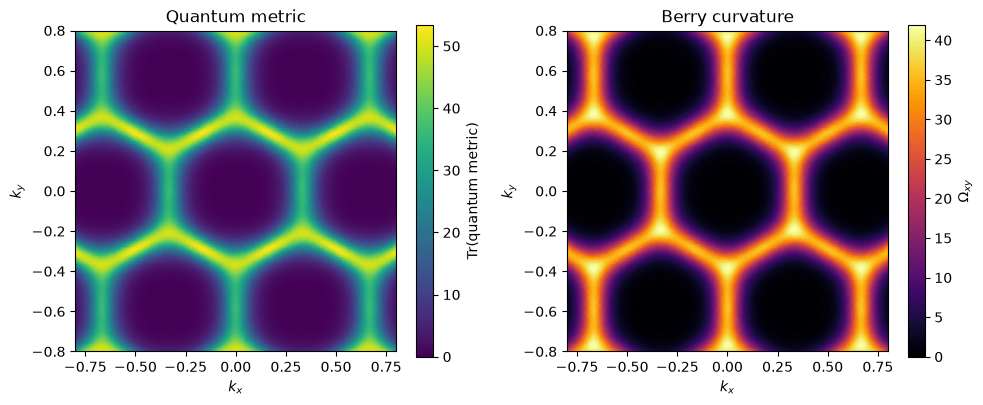

In [2]:
ks,Qs = topology.quantum_geometric_tensor_mesh(h,nk=40,occ_idxs=[0,1]) # QGT on a k-mesh
metric_mesh = np.array([np.trace(q).real for q in topology.quantum_metric_from_qgt(Qs)]) # Tr(g)
berry_mesh = topology.berry_curvature_from_qgt(Qs)[:,0,1] # Omega_xy

B = np.array([g.b1[:2],g.b2[:2]]) # reciprocal lattice vectors
kc,mc,bc = [],[],[] # k-points, metric and curvature, repeated over neighboring cells
for n1 in range(-2,2):
    for n2 in range(-2,2):
        kc.append((np.array(ks)[:,:2]+np.array([n1,n2]))@B) # cartesian k-points
        mc.append(metric_mesh) ; bc.append(berry_mesh)
kc = np.concatenate(kc) ; mc = np.concatenate(mc) ; bc = np.concatenate(bc)

fig,axs = plt.subplots(1,2,figsize=(10,4))
s = axs[0].tripcolor(kc[:,0],kc[:,1],mc,cmap="viridis",shading="gouraud")
fig.colorbar(s,ax=axs[0],label="Tr(quantum metric)")
axs[0].set_title("Quantum metric")
s = axs[1].tripcolor(kc[:,0],kc[:,1],bc,cmap="inferno",shading="gouraud")
fig.colorbar(s,ax=axs[1],label="$\\Omega_{xy}$")
axs[1].set_title("Berry curvature")
for ax in axs:
    ax.set_xlim(-0.8,0.8) ; ax.set_ylim(-0.8,0.8) ; ax.set_aspect("equal")
    ax.set_xlabel("$k_x$") ; ax.set_ylabel("$k_y$")
plt.tight_layout()
plt.show()